In [ ]:
%pip install neurokit2 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 29.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import neurokit2 as nk

# Generate some example data
x = np.random.rand(1000)

# Calculate sample entropy
sampen_nk = nk.entropy_sample(x, dimension=2, delay=1, tolerance=.2)

# Calculate multiscale entropy, limiting to 12 scales
mse_nk= nk.entropy_multiscale(x, scale_min=1, scale_max=12, dimension=2, delay=1, r=.2)

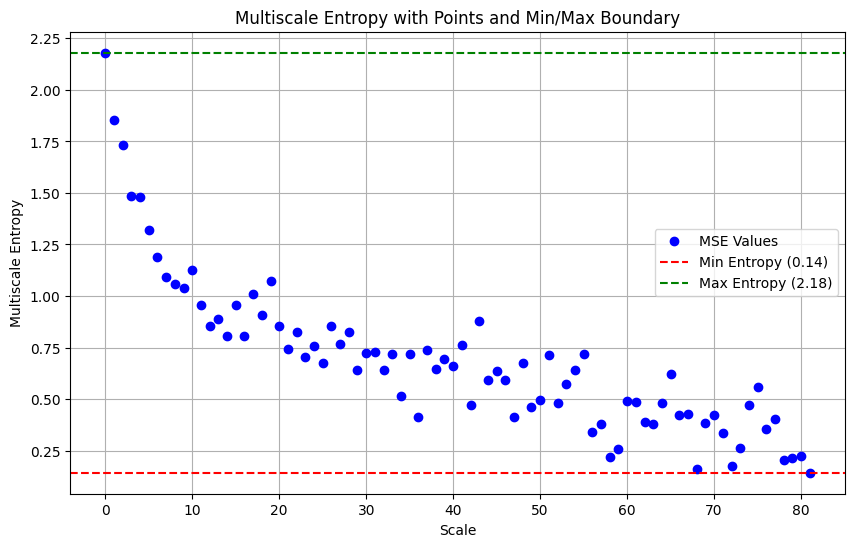

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get the entropy values
entropy_values = mse_nk[1]['Value']

# Plot the entropy values with markers for points, without a connecting line
plt.figure(figsize=(10, 6))
plt.plot(entropy_values, marker='o', linestyle='', color='blue', label='MSE Values')

# Add boundary lines (min and max entropy values)
min_entropy = np.min(entropy_values)
max_entropy = np.max(entropy_values)

plt.axhline(min_entropy, color='red', linestyle='--', label=f'Min Entropy ({min_entropy:.2f})')
plt.axhline(max_entropy, color='green', linestyle='--', label=f'Max Entropy ({max_entropy:.2f})')

# Add labels and title for clarity
plt.xlabel('Scale')
plt.ylabel('Multiscale Entropy')
plt.title('Multiscale Entropy with Points and Min/Max Boundary')
plt.legend()
plt.grid(True)
plt.show()

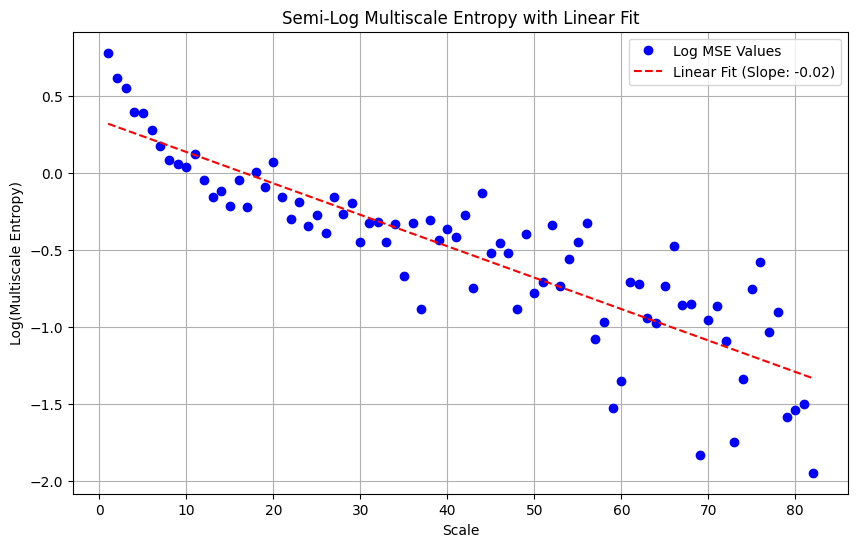

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Get the entropy values and scale values
entropy_values = mse_nk[1]['Value']
scale_values = mse_nk[1]['Scale']

# Filter out scales where entropy is non-positive before taking log for y-axis
positive_entropy_indices = entropy_values > 0
# X-axis will be original scale values (linear)
linear_scale_values = scale_values[positive_entropy_indices]
log_entropy_values = np.log(entropy_values[positive_entropy_indices]) # Y-axis remains log

# Perform linear regression for a semi-log plot (log_y vs x)
# This assumes a model of log(entropy) = slope * scale + intercept
slope, intercept, r_value, p_value, std_err = linregress(linear_scale_values, log_entropy_values)
regression_line_log_y = slope * linear_scale_values + intercept

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(linear_scale_values, log_entropy_values, marker='o', linestyle='', color='blue', label='Log MSE Values')
plt.plot(linear_scale_values, regression_line_log_y, color='red', linestyle='--', label=f'Linear Fit (Slope: {slope:.2f})')

# Add labels and title for clarity
plt.xlabel('Scale') # X-axis label is now 'Scale' (linear)
plt.ylabel('Log(Multiscale Entropy)')
plt.title('Semi-Log Multiscale Entropy with Linear Fit')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

#mse_nk
#mse_nk[1]['Value'][0]
#mse_nk[0]
mse_nk[1]['Value'][0:20]

array([2.13863041, 1.90398046, 1.63874058, 1.52784762, 1.33307366,
       1.30862132, 1.16432936, 1.10747872, 1.0712508 , 1.03062495,
       0.93949363, 1.00814269, 0.81757476, 1.12507886, 0.97035795,
       0.8196639 , 0.87403092, 0.94221442, 0.76270486, 0.76823763])

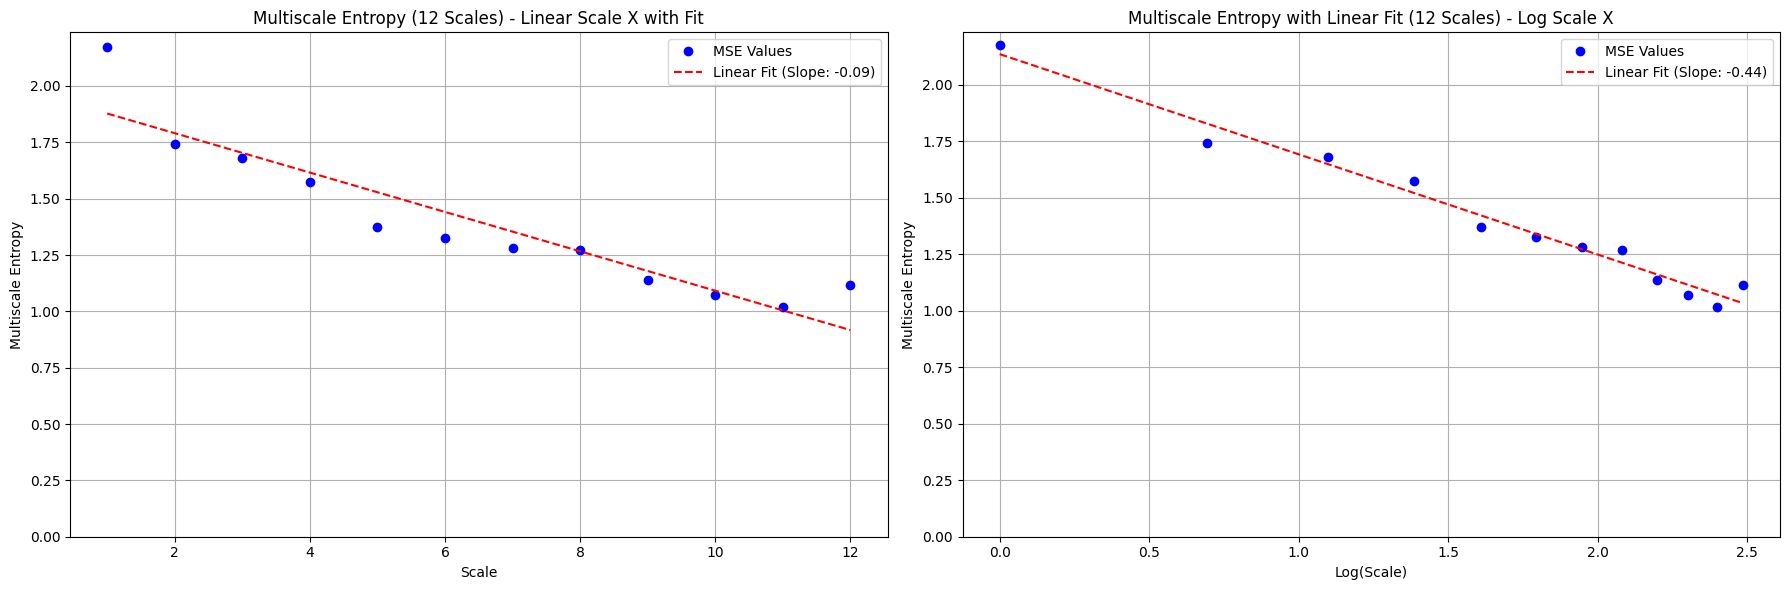

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Get the entropy values and scale values from the updated mse_nk
entropy_values = mse_nk[1]['Value'][:12] # Slice to the first 12 scales
scale_values = mse_nk[1]['Scale'][:12] # Slice to the first 12 scales

# Calculate log of scale values for the x-axis for the right plot
log_scale_values = np.log(scale_values)

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: Linear Scale vs Linear Entropy (with points and Linear Fit) ---
ax1 = axes[0]

# Perform linear regression for a linear-linear plot
slope_linear, intercept_linear, r_value_linear, p_value_linear, std_err_linear = linregress(scale_values, entropy_values)
regression_line_linear_y = slope_linear * scale_values + intercept_linear

ax1.plot(scale_values, entropy_values, marker='o', linestyle='', color='blue', label='MSE Values')
ax1.plot(scale_values, regression_line_linear_y, color='red', linestyle='--', label=f'Linear Fit (Slope: {slope_linear:.2f})')

ax1.set_xlabel('Scale')
ax1.set_ylabel('Multiscale Entropy')
ax1.set_title('Multiscale Entropy (12 Scales) - Linear Scale X with Fit')
ax1.legend()
ax1.grid(True)
ax1.set_ylim(bottom=0) # Ensure Y-axis starts at 0

# --- Plot 2: Log Scale vs Linear Entropy (with Linear Fit) ---
ax2 = axes[1]

# Perform linear regression for a semi-log plot (linear y vs log x)
slope_linear_logx, intercept_linear_logx, r_value_linear_logx, p_value_linear_logx, std_err_linear_logx = linregress(log_scale_values, entropy_values)
regression_line_linear_logx = slope_linear_logx * log_scale_values + intercept_linear_logx

ax2.plot(log_scale_values, entropy_values, marker='o', linestyle='', color='blue', label='MSE Values')
ax2.plot(log_scale_values, regression_line_linear_logx, color='red', linestyle='--', label=f'Linear Fit (Slope: {slope_linear_logx:.2f})')

ax2.set_xlabel('Log(Scale)')
ax2.set_ylabel('Multiscale Entropy')
ax2.set_title('Multiscale Entropy with Linear Fit (12 Scales) - Log Scale X')
ax2.legend()
ax2.grid(True)
ax2.set_ylim(bottom=0) # Ensure Y-axis starts at 0

plt.tight_layout()
plt.show()

In [ ]:
sampen_nk[0]

#help(nk.entropy_sample)

np.float64(1.0189927741174218)

In [ ]:
signal = nk.signal_simulate(duration=2, frequency=5)
entropy = nk.entropy_sample(signal)
entropy #doctest: +SKIP

(np.float64(0.07380851770121913),
 {'Dimension': 2,
  'Delay': 1,
  'Tolerance': np.float64(0.07072836242007384),
  'phi': array([0.13427699, 0.12472312])})

In [ ]:
# Coarse graining for the first scale
#x_cg1 = nk.coarse_graining(x, 2)
sampen_cg1_nk = nk.entropy_multiscale(x, scale=list(range(1, 21)), dimension=2, r=0.2)

# Coarse graining for the second scale
#x_cg2 = nk.coarse_graining(x, 4)
#sampen_cg2_nk = nk.entropy_multiscale(x, scale= 3, dimension=2, r=0.2)

# Print the results
print("Sample entropy for the original signal:", sampen_nk)
print("Sample entropy for the first coarse-grained signal:", sampen_cg1_nk)
print("Sample entropy for the second coarse-grained signal:", sampen_cg2_nk)

NameError: name 'nk' is not defined

In [ ]:
signal = x
import numpy as np

def coarse_graining(signal, scale):
    if len(signal) % scale != 0:
        signal = signal[:-(len(signal) % scale)]  # Truncate signal to make it evenly divisible by scale
    reshaped = signal.reshape(-1, scale)  # Reshape signal into scale-sized blocks
    return np.mean(reshaped, axis=1)  # Compute mean of each block and return as a new signal


In [ ]:
coarse_graining(x, 4)

array([0.50162367, 0.50808913, 0.51545885, 0.50702746, 0.56743467,
       0.5156174 , 0.21927213, 0.5007845 , 0.66023248, 0.72119638,
       0.45697367, 0.45890426, 0.2594631 , 0.54416313, 0.39036736,
       0.40185179, 0.48927343, 0.62351293, 0.72919669, 0.49977955,
       0.54058002, 0.44880465, 0.57603695, 0.40414596, 0.22487839,
       0.24042622, 0.26277264, 0.72324452, 0.64168585, 0.47669595,
       0.25868308, 0.61589652, 0.38680746, 0.40799583, 0.51600134,
       0.54717332, 0.6929963 , 0.54852876, 0.41733077, 0.32344297,
       0.54336138, 0.70781708, 0.4743293 , 0.50182369, 0.45713178,
       0.65715546, 0.53318149, 0.78687999, 0.55365898, 0.59547174,
       0.6388925 , 0.46988806, 0.58142215, 0.49971437, 0.72263863,
       0.61125629, 0.31053638, 0.63828946, 0.58500762, 0.32326387,
       0.8036397 , 0.59336399, 0.44582064, 0.39217518, 0.5217969 ,
       0.56492717, 0.28039181, 0.41255817, 0.40172432, 0.7448955 ,
       0.41417665, 0.54439804, 0.79870464, 0.58482462, 0.43796

In [ ]:
# Perform coarse-graining on first and second scales
cg1 = coarse_graining(x, 2)
cg2 = coarse_graining(x, 4)

# Compute sample entropy of coarse-grained signals
va1 = nk.entropy_sample(cg1, dimension=2, r=0.2, scale=1)
va2 = nk.entropy_sample(cg2, dimension=2, r=0.2, scale=1)


In [ ]:
va1

(2.2405706168885566,
 {'Dimension': 2, 'Delay': 1, 'Tolerance': 0.040635481787708094})

In [ ]:
va2

(2.074527526877407,
 {'Dimension': 2, 'Delay': 1, 'Tolerance': 0.029194129432320855})